# MNIST: Embedded Interpolants (28×28, no PCA)

Direct fit on pixel space (d=784, 28×28 digits).  No dimensionality reduction.

1. Per-digit generation (fit on one class, generate fresh)
2. **Unconditional**: single model on all digits, sample noise → get random digit
3. Evolution: watch noise turn into digits


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
import sys
sys.path.insert(0, '..')
from src import EmbeddedInterpolants, sliced_wasserstein1

np.random.seed(42)
%matplotlib inline
plt.rcParams['figure.dpi'] = 140


In [21]:
# fetch MNIST 28x28 — primary path via openml; fallback to GitHub mirror if blocked
def load_mnist():
    try:
        mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
        X = mnist.data.astype(np.float32) / 255.0
        y = mnist.target.astype(np.int64)
        print(f'MNIST via openml: X={X.shape}, y={y.shape}')
        return X, y
    except Exception as e:
        print(f'openml non disponibile ({type(e).__name__}); fallback al mirror GitHub fgnt/mnist...')
    import gzip, struct, subprocess, tempfile
    from pathlib import Path
    td = Path(tempfile.gettempdir()) / 'mnist-data'
    if not td.exists():
        subprocess.run(['git','clone','--depth','1',
                        'https://github.com/fgnt/mnist.git', str(td)], check=True)
    def read_idx_images(path):
        with gzip.open(path, 'rb') as f:
            magic, n, h, w = struct.unpack('>IIII', f.read(16))
            return np.frombuffer(f.read(), dtype=np.uint8).reshape(n, h*w)
    def read_idx_labels(path):
        with gzip.open(path, 'rb') as f:
            magic, n = struct.unpack('>II', f.read(8))
            return np.frombuffer(f.read(), dtype=np.uint8)
    Xtr = read_idx_images(td / 'train-images-idx3-ubyte.gz')
    ytr = read_idx_labels(td / 'train-labels-idx1-ubyte.gz')
    Xte = read_idx_images(td / 't10k-images-idx3-ubyte.gz')
    yte = read_idx_labels(td / 't10k-labels-idx1-ubyte.gz')
    X = np.concatenate([Xtr, Xte]).astype(np.float32) / 255.0
    y = np.concatenate([ytr, yte]).astype(np.int64)
    print(f'MNIST via GitHub mirror: X={X.shape}, y={y.shape}')
    return X, y

X_full, y_full = load_mnist()

# subsample uniformly per digit so the per-class experiments are tractable
N_PER_CLASS = 600       # → 6000 total
sub_idx = []
for digit in range(10):
    cls = np.where(y_full == digit)[0]
    pick = np.random.choice(cls, size=min(N_PER_CLASS, len(cls)), replace=False)
    sub_idx.append(pick)
sub_idx = np.concatenate(sub_idx)
np.random.shuffle(sub_idx)
X_all = X_full[sub_idx]
y_all = y_full[sub_idx]
print(f'subsampled: {X_all.shape}, balanced ~{N_PER_CLASS}/class')


MNIST via openml: X=(70000, 784), y=(70000,)
subsampled: (6000, 784), balanced ~600/class


In [22]:
def show_digits(images, n=10, title='', ax=None):
    if ax is None: fig,ax=plt.subplots(1,1,figsize=(n*1.4,1.7))
    strip=np.ones((28, 29*n-1))*0.0
    for i in range(min(n,len(images))):
        strip[:, i*29:i*29+28] = np.clip(images[i].reshape(28,28), 0, 1)
    ax.imshow(strip,cmap='gray_r',interpolation='nearest',aspect='auto',vmin=0,vmax=1)
    ax.set_title(title,fontweight='bold',fontsize=10); ax.set_xticks([]);ax.set_yticks([])
    return ax


---
## 1. Per-digit generation (all 10 digits)


In [47]:
d = 784
results = {}

for digit in range(10):
    mask = y_all == digit
    X_d = X_all[mask]
    scale = np.maximum(np.std(X_d, axis=0, keepdims=True), 1e-3)
    X_d_n = X_d / scale
    idx = np.random.permutation(len(X_d))
    n_train = int(0.8 * len(X_d))
    X_train = X_d_n[idx[:n_train]]
    X_test  = X_d_n[idx[n_train:]]

    n_src  = 500
    n_test = 500

    model = EmbeddedInterpolants(sigma_k=None, gamma=0.01, gamma_final=1e-8, K_steps=80, n_inducing=150, q=0.5, q_final=0.1)
    model.fit(np.random.randn(n_src, d), X_train,
              n_iterations=8, verbose=True)
    res = model.transport(np.random.randn(n_test, d))
    sw = sliced_wasserstein1(res['particles'], X_test)

    results[digit] = {
        'sw': sw,
        'model': model,
        'res': res,
        'scale': scale,
        'real': X_d[idx[:50]],
        'train_pixels': np.clip(model._fit_result['particles'] * scale, 0, 1),
        'fresh_pixels': np.clip(res['particles'] * scale, 0, 1),
    }
    print(f"Digit {digit}: SW1={sw:.3f}  η_final={model._fit_result['lift_ratios'][-1]:.3f}")


  Bandwidth (quantile, decaying q=0.5->0.1): sigma_init=39.2480
  Iter 1: lift_ratio=0.570,  gamma=0.01000,  q=0.500,  sigma=39.248,  M=150
  Iter 2: lift_ratio=0.553,  gamma=0.00857,  q=0.443,  sigma=38.886,  M=150
  Iter 3: lift_ratio=0.502,  gamma=0.00714,  q=0.386,  sigma=38.459,  M=150
  Iter 4: lift_ratio=0.515,  gamma=0.00571,  q=0.329,  sigma=37.865,  M=150
  Iter 5: lift_ratio=0.467,  gamma=0.00429,  q=0.271,  sigma=36.853,  M=150
  Iter 6: lift_ratio=0.416,  gamma=0.00286,  q=0.214,  sigma=35.046,  M=150
  Iter 7: lift_ratio=0.352,  gamma=0.00143,  q=0.157,  sigma=31.011,  M=150
  Iter 8: lift_ratio=0.322,  gamma=0.00000,  q=0.100,  sigma=26.990,  M=150
Digit 0: SW1=0.191  η_final=0.322
  Bandwidth (quantile, decaying q=0.5->0.1): sigma_init=38.4402
  Iter 1: lift_ratio=0.562,  gamma=0.01000,  q=0.500,  sigma=38.440,  M=150
  Iter 2: lift_ratio=0.520,  gamma=0.00857,  q=0.443,  sigma=37.975,  M=150
  Iter 3: lift_ratio=0.425,  gamma=0.00714,  q=0.386,  sigma=37.429,  M=150
  

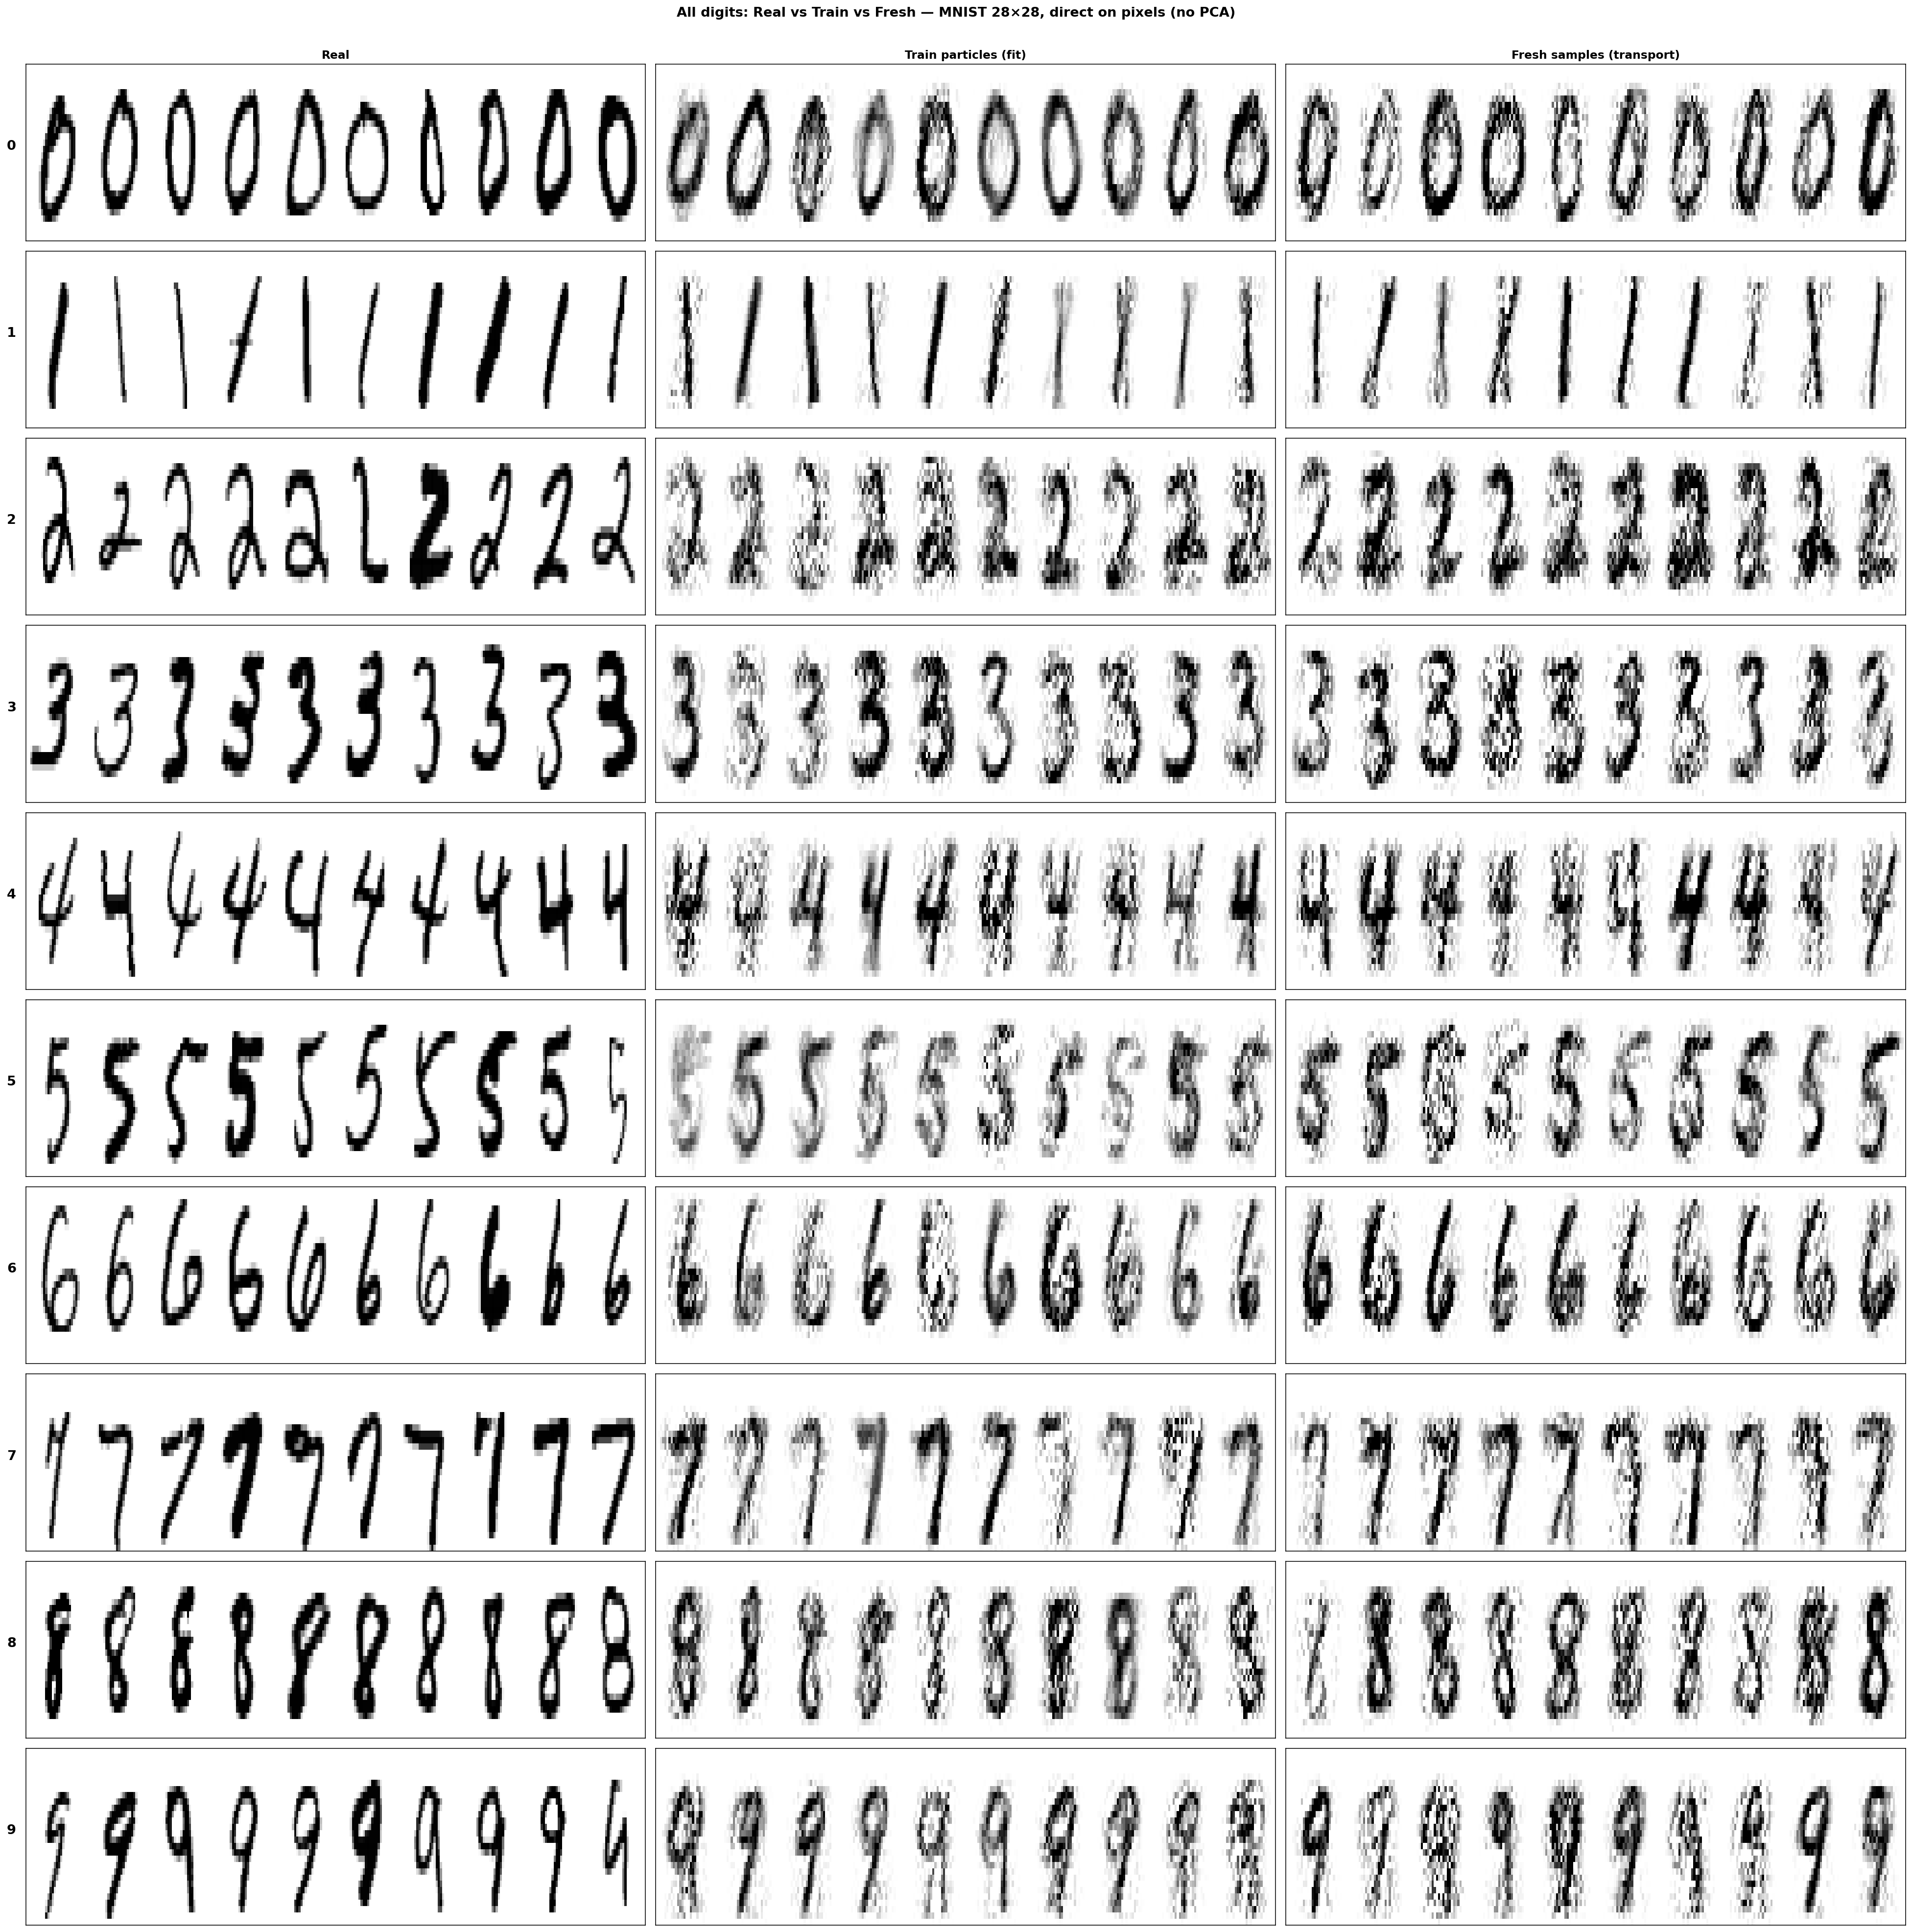

In [24]:
fig, axes = plt.subplots(10, 3, figsize=(28, 28))
for digit in range(10):
    r = results[digit]
    show_digits(r['real'], n=10, ax=axes[digit,0])
    show_digits(r['train_pixels'], n=10, ax=axes[digit,1])
    show_digits(r['fresh_pixels'], n=10, ax=axes[digit,2])
    axes[digit,0].set_ylabel(f'{digit}', fontsize=14, fontweight='bold', rotation=0, labelpad=15)
    if digit==0:
        axes[digit,0].set_title('Real', fontsize=12, fontweight='bold')
        axes[digit,1].set_title('Train particles (fit)', fontsize=12, fontweight='bold')
        axes[digit,2].set_title('Fresh samples (transport)', fontsize=12, fontweight='bold')
fig.suptitle('All digits: Real vs Train vs Fresh — MNIST 28×28, direct on pixels (no PCA)', fontweight='bold', fontsize=14, y=1.005)
plt.tight_layout(); plt.show()


### 1.b — Stress test: only 1 velocity field

Same as above but with `n_iterations=1` instead of 3.  Tests how well a single Bures map already pushes noise toward digits without iterative refinement.


In [45]:
results_1iter = {}

for digit in range(10):
    mask = y_all == digit
    X_d = X_all[mask]
    scale = np.maximum(np.std(X_d, axis=0, keepdims=True), 1e-3)
    X_d_n = X_d / scale
    idx = np.random.permutation(len(X_d))
    n_train = int(0.8 * len(X_d))
    X_train = X_d_n[idx[:n_train]]
    X_test  = X_d_n[idx[n_train:]]

    n_src  = 500
    n_test = 500

    model = EmbeddedInterpolants(sigma_k=None, gamma=0.01, gamma_final=1e-8, K_steps=80, n_inducing=150, q=0.5, q_final=0.1)
    model.fit(np.random.randn(n_src, d), X_train,
              n_iterations=1, verbose=True)
    res = model.transport(np.random.randn(n_test, d))
    sw = sliced_wasserstein1(res['particles'], X_test)

    results_1iter[digit] = {
        'sw': sw,
        'model': model,
        'res': res,
        'scale': scale,
        'real': X_d[idx[:50]],
        'train_pixels': np.clip(model._fit_result['particles'] * scale, 0, 1),
        'fresh_pixels': np.clip(res['particles'] * scale, 0, 1),
    }
    print(f"Digit {digit}: SW1={sw:.3f}")


  Bandwidth (quantile, decaying q=0.5->0.1): sigma_init=39.2200
  Iter 1: lift_ratio=0.570,  gamma=0.01000,  q=0.500,  sigma=39.220,  M=150
Digit 0: SW1=0.285
  Bandwidth (quantile, decaying q=0.5->0.1): sigma_init=38.5103
  Iter 1: lift_ratio=0.562,  gamma=0.01000,  q=0.500,  sigma=38.510,  M=150
Digit 1: SW1=0.339
  Bandwidth (quantile, decaying q=0.5->0.1): sigma_init=38.7917
  Iter 1: lift_ratio=0.571,  gamma=0.01000,  q=0.500,  sigma=38.792,  M=150
Digit 2: SW1=0.233
  Bandwidth (quantile, decaying q=0.5->0.1): sigma_init=38.6068
  Iter 1: lift_ratio=0.569,  gamma=0.01000,  q=0.500,  sigma=38.607,  M=150
Digit 3: SW1=0.251
  Bandwidth (quantile, decaying q=0.5->0.1): sigma_init=38.1076
  Iter 1: lift_ratio=0.564,  gamma=0.01000,  q=0.500,  sigma=38.108,  M=150
Digit 4: SW1=0.243
  Bandwidth (quantile, decaying q=0.5->0.1): sigma_init=37.8472
  Iter 1: lift_ratio=0.557,  gamma=0.01000,  q=0.500,  sigma=37.847,  M=150
Digit 5: SW1=0.263
  Bandwidth (quantile, decaying q=0.5->0.1): s

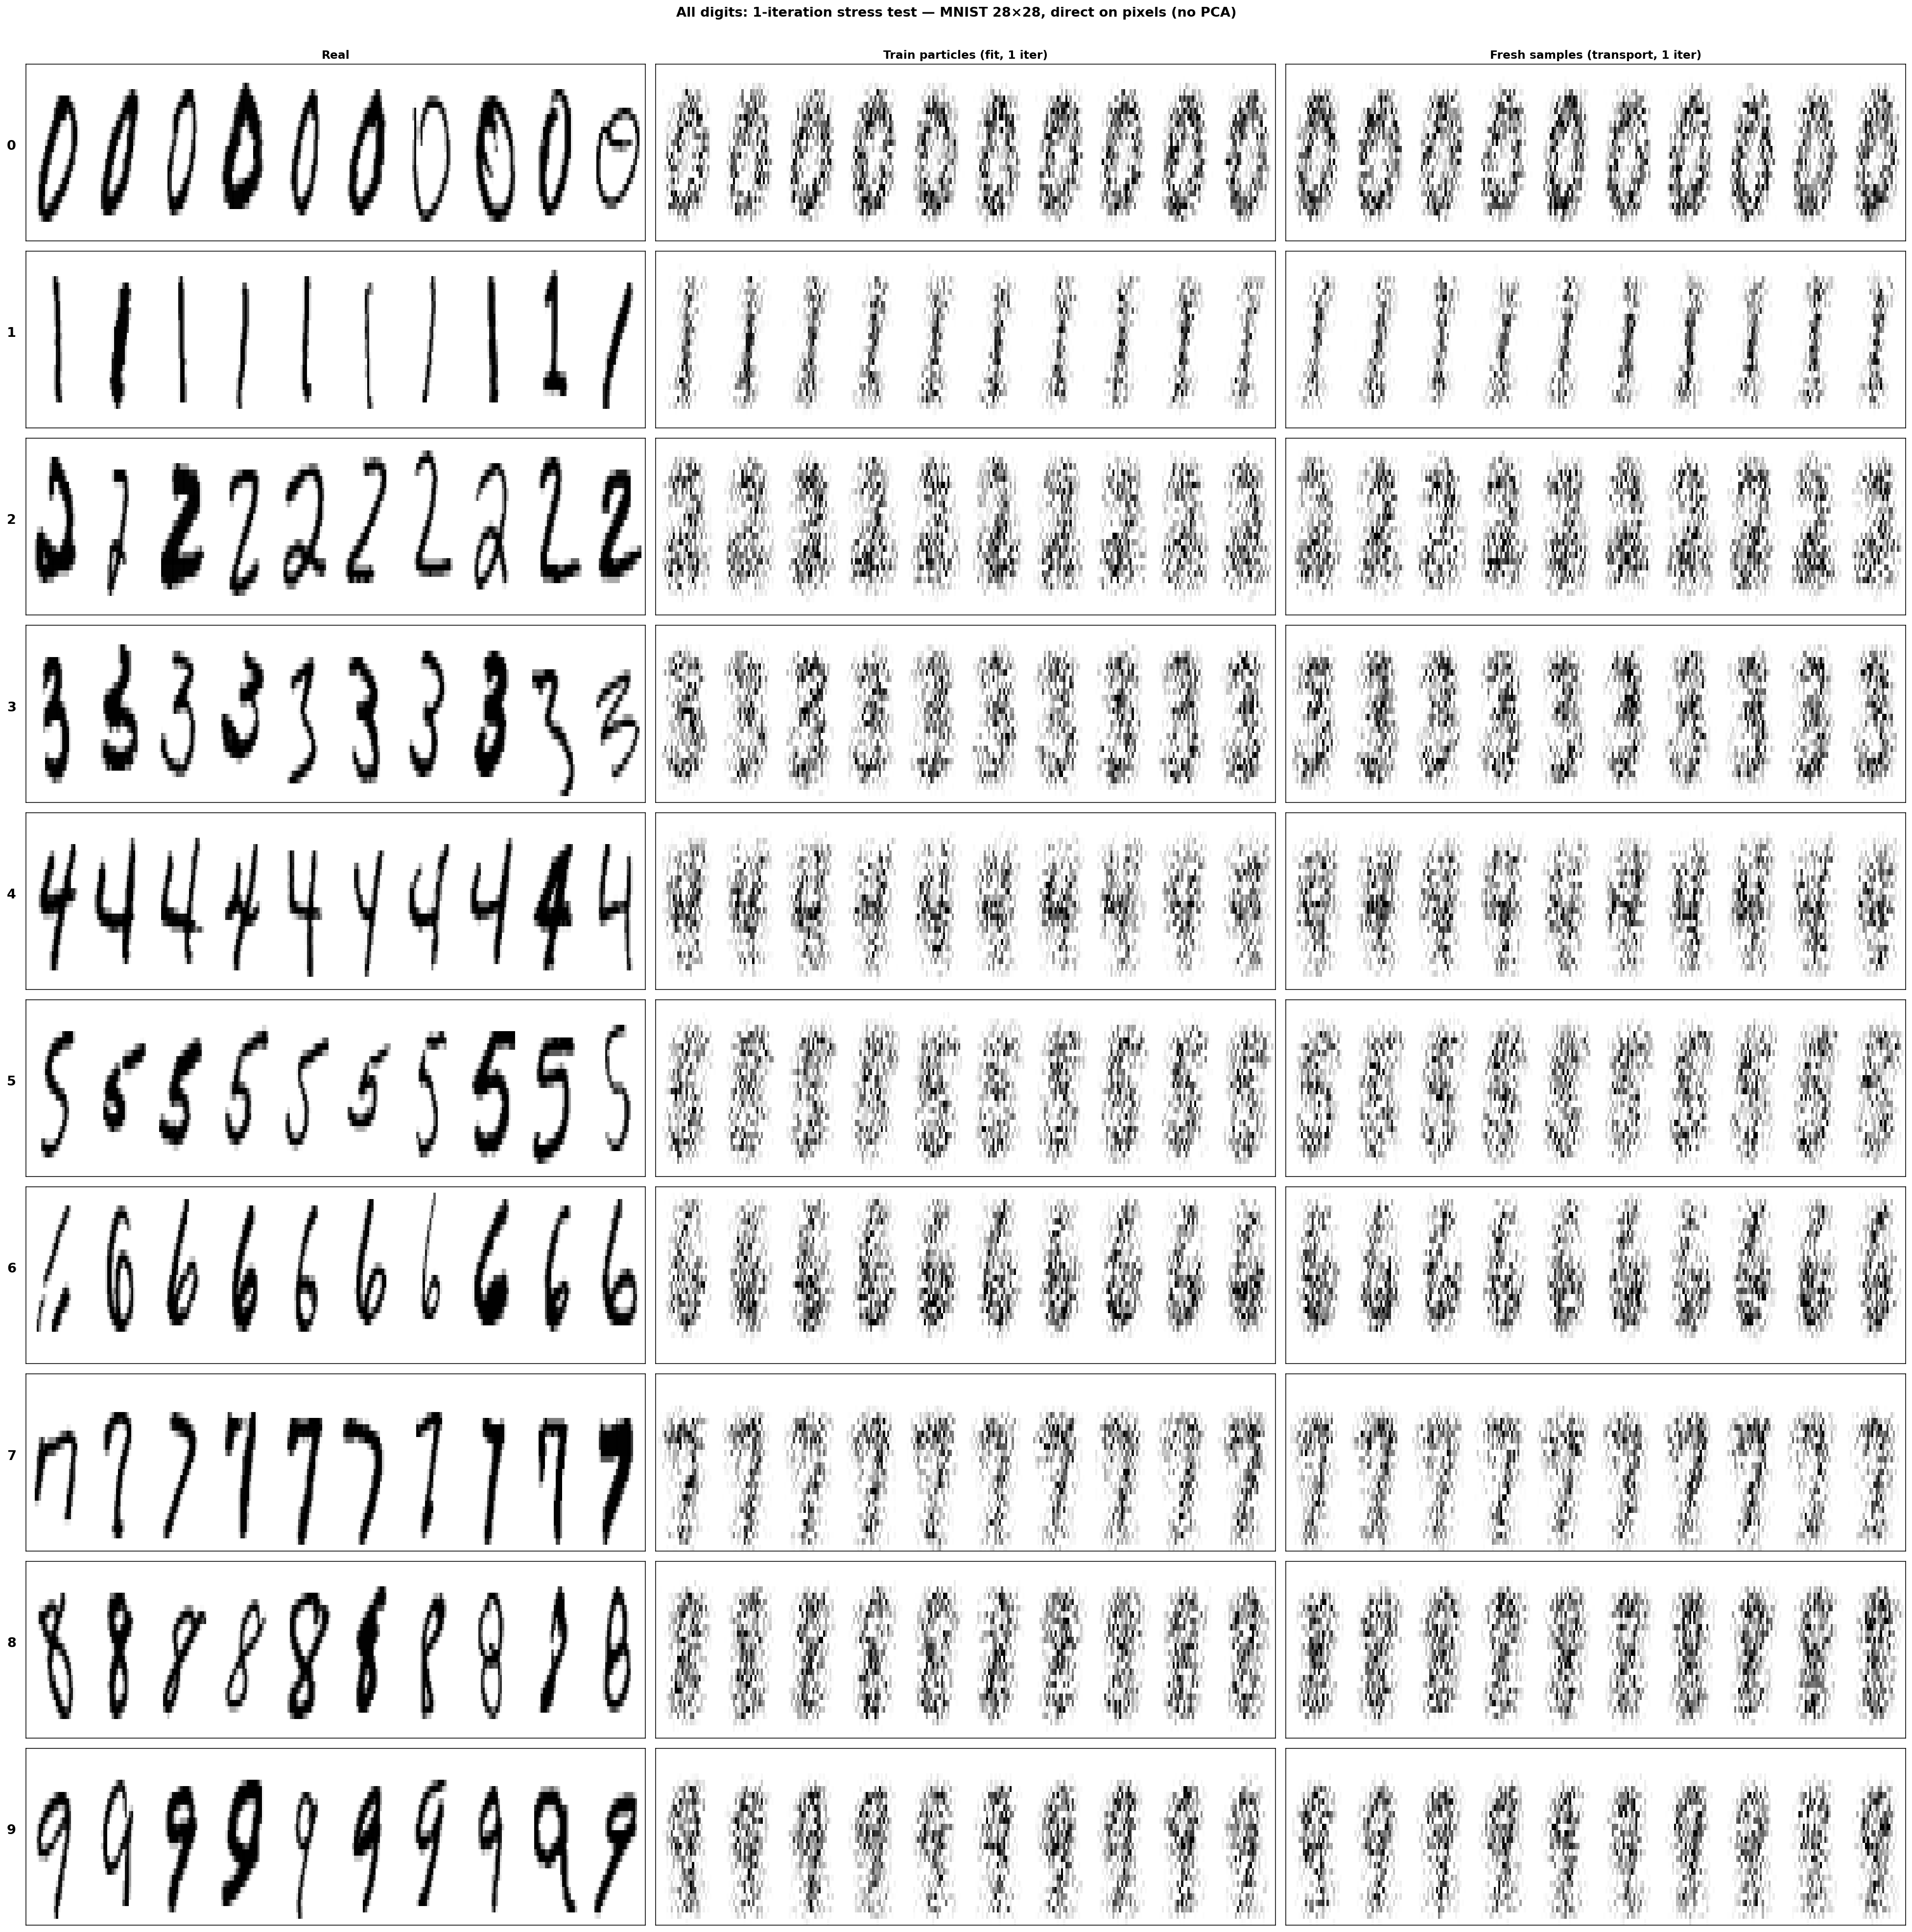

In [46]:
fig, axes = plt.subplots(10, 3, figsize=(28, 28))
for digit in range(10):
    r = results_1iter[digit]
    show_digits(r['real'], n=10, ax=axes[digit,0])
    show_digits(r['train_pixels'], n=10, ax=axes[digit,1])
    show_digits(r['fresh_pixels'], n=10, ax=axes[digit,2])
    axes[digit,0].set_ylabel(f'{digit}', fontsize=14, fontweight='bold', rotation=0, labelpad=15)
    if digit==0:
        axes[digit,0].set_title('Real', fontsize=12, fontweight='bold')
        axes[digit,1].set_title('Train particles (fit, 1 iter)', fontsize=12, fontweight='bold')
        axes[digit,2].set_title('Fresh samples (transport, 1 iter)', fontsize=12, fontweight='bold')
fig.suptitle('All digits: 1-iteration stress test — MNIST 28×28, direct on pixels (no PCA)', fontweight='bold', fontsize=14, y=1.005)
plt.tight_layout(); plt.show()


---
## 2. Unconditional: single model, all digits


In [27]:
# fit on ALL digits together, directly on pixels
scale_all = np.maximum(np.std(X_all, axis=0, keepdims=True), 1e-3)
X_all_n = X_all / scale_all

idx_all = np.random.permutation(len(X_all))
n_tr_uncond = int(0.85 * len(X_all))
X_train_all = X_all_n[idx_all[:n_tr_uncond]]
X_test_all  = X_all_n[idx_all[n_tr_uncond:]]

print(f'Direct on pixels: d={d}')
print(f'Train: {len(X_train_all)}, Test: {len(X_test_all)}')


Direct on pixels: d=784
Train: 5100, Test: 900


In [37]:
model_all = EmbeddedInterpolants(sigma_k=None, gamma=0.01, gamma_final=1e-8, K_steps=80, n_inducing=500, q=0.5, q_final=0.1)
print('FIT:')
model_all.fit(np.random.randn(2000, d), X_train_all, n_iterations=10)

print('\nTRANSPORT:')
X0_fresh = np.random.randn(1000, d)
res_all = model_all.transport(X0_fresh, verbose=True)


FIT:
  Bandwidth (quantile, decaying q=0.5->0.1): sigma_init=35.8026
  Iter 1: lift_ratio=0.526,  gamma=0.01000,  q=0.500,  sigma=35.988,  M=500
  Iter 2: lift_ratio=0.490,  gamma=0.00889,  q=0.456,  sigma=35.214,  M=500
  Iter 3: lift_ratio=0.414,  gamma=0.00778,  q=0.411,  sigma=34.656,  M=500
  Iter 4: lift_ratio=0.416,  gamma=0.00667,  q=0.367,  sigma=33.374,  M=500
  Iter 5: lift_ratio=0.382,  gamma=0.00556,  q=0.322,  sigma=32.498,  M=500
  Iter 6: lift_ratio=0.316,  gamma=0.00444,  q=0.278,  sigma=31.301,  M=500
  Iter 7: lift_ratio=0.261,  gamma=0.00333,  q=0.233,  sigma=30.165,  M=500
  Iter 8: lift_ratio=0.218,  gamma=0.00222,  q=0.189,  sigma=28.611,  M=500
  Iter 9: lift_ratio=0.188,  gamma=0.00111,  q=0.144,  sigma=26.527,  M=500
  Iter 10: lift_ratio=0.186,  gamma=0.00000,  q=0.100,  sigma=24.724,  M=500

TRANSPORT:
  Iter 1: lift_ratio=0.523
  Iter 2: lift_ratio=0.485
  Iter 3: lift_ratio=0.408
  Iter 4: lift_ratio=0.412
  Iter 5: lift_ratio=0.380
  Iter 6: lift_ratio=0.

In [43]:
gen_pixels = np.clip(res_all['particles'] * scale_all, 0, 1)

# classify with KNN directly on pixels
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_all_n, y_all)
gen_labels = knn.predict(res_all['particles'])

print('Generated digit distribution:')
for digit in range(10):
    n_d = np.sum(gen_labels==digit)
    print(f'  Digit {digit}: {n_d}/1000 ({n_d/10:.0f}%)')


Generated digit distribution:
  Digit 0: 158/1000 (16%)
  Digit 1: 205/1000 (20%)
  Digit 2: 24/1000 (2%)
  Digit 3: 84/1000 (8%)
  Digit 4: 127/1000 (13%)
  Digit 5: 68/1000 (7%)
  Digit 6: 73/1000 (7%)
  Digit 7: 69/1000 (7%)
  Digit 8: 71/1000 (7%)
  Digit 9: 121/1000 (12%)


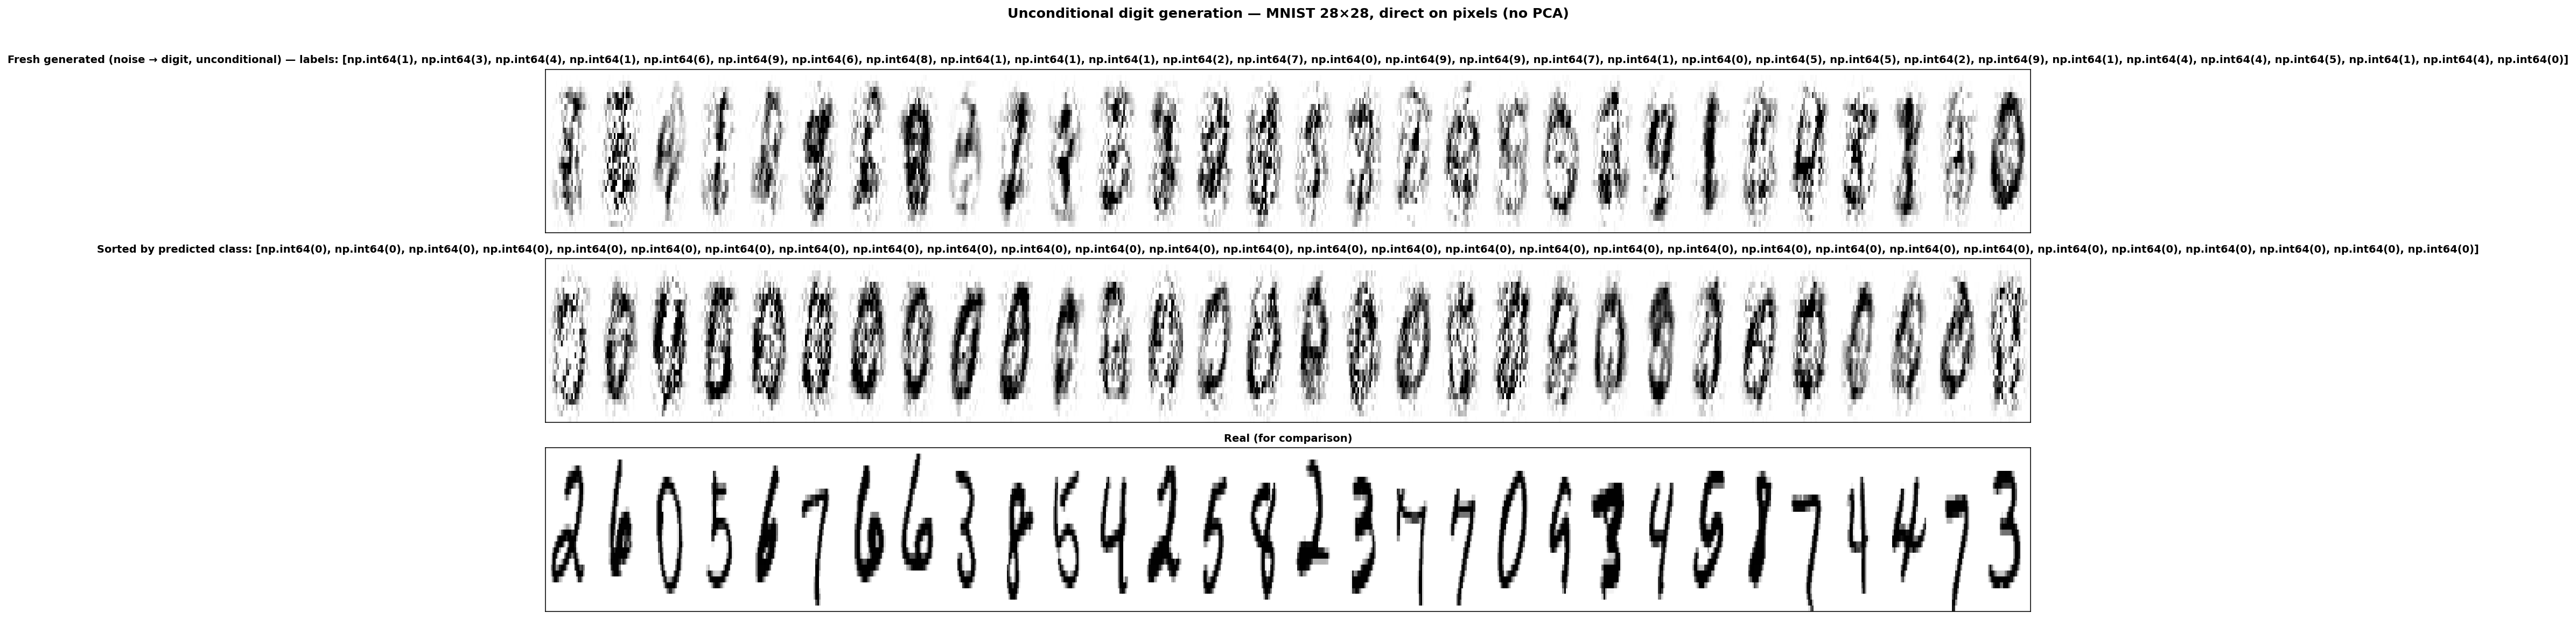

In [44]:
# Big display: generated samples
n_show = 30
fig, axes = plt.subplots(3, 1, figsize=(20, 8))

# Row 0: fresh generated
show_digits(gen_pixels, n=n_show, ax=axes[0],
            title=f'Fresh generated (noise → digit, unconditional) — labels: {list(gen_labels[:n_show])}')

# Row 1: sorted by class
sorted_idx = np.argsort(gen_labels)
show_digits(gen_pixels[sorted_idx], n=n_show, ax=axes[1],
            title=f'Sorted by predicted class: {list(gen_labels[sorted_idx[:n_show]])}')

# Row 2: real for comparison
real_show = X_all[np.random.choice(len(X_all), n_show, replace=False)]
show_digits(real_show, n=n_show, ax=axes[2], title='Real (for comparison)')

fig.suptitle('Unconditional digit generation — MNIST 28×28, direct on pixels (no PCA)', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


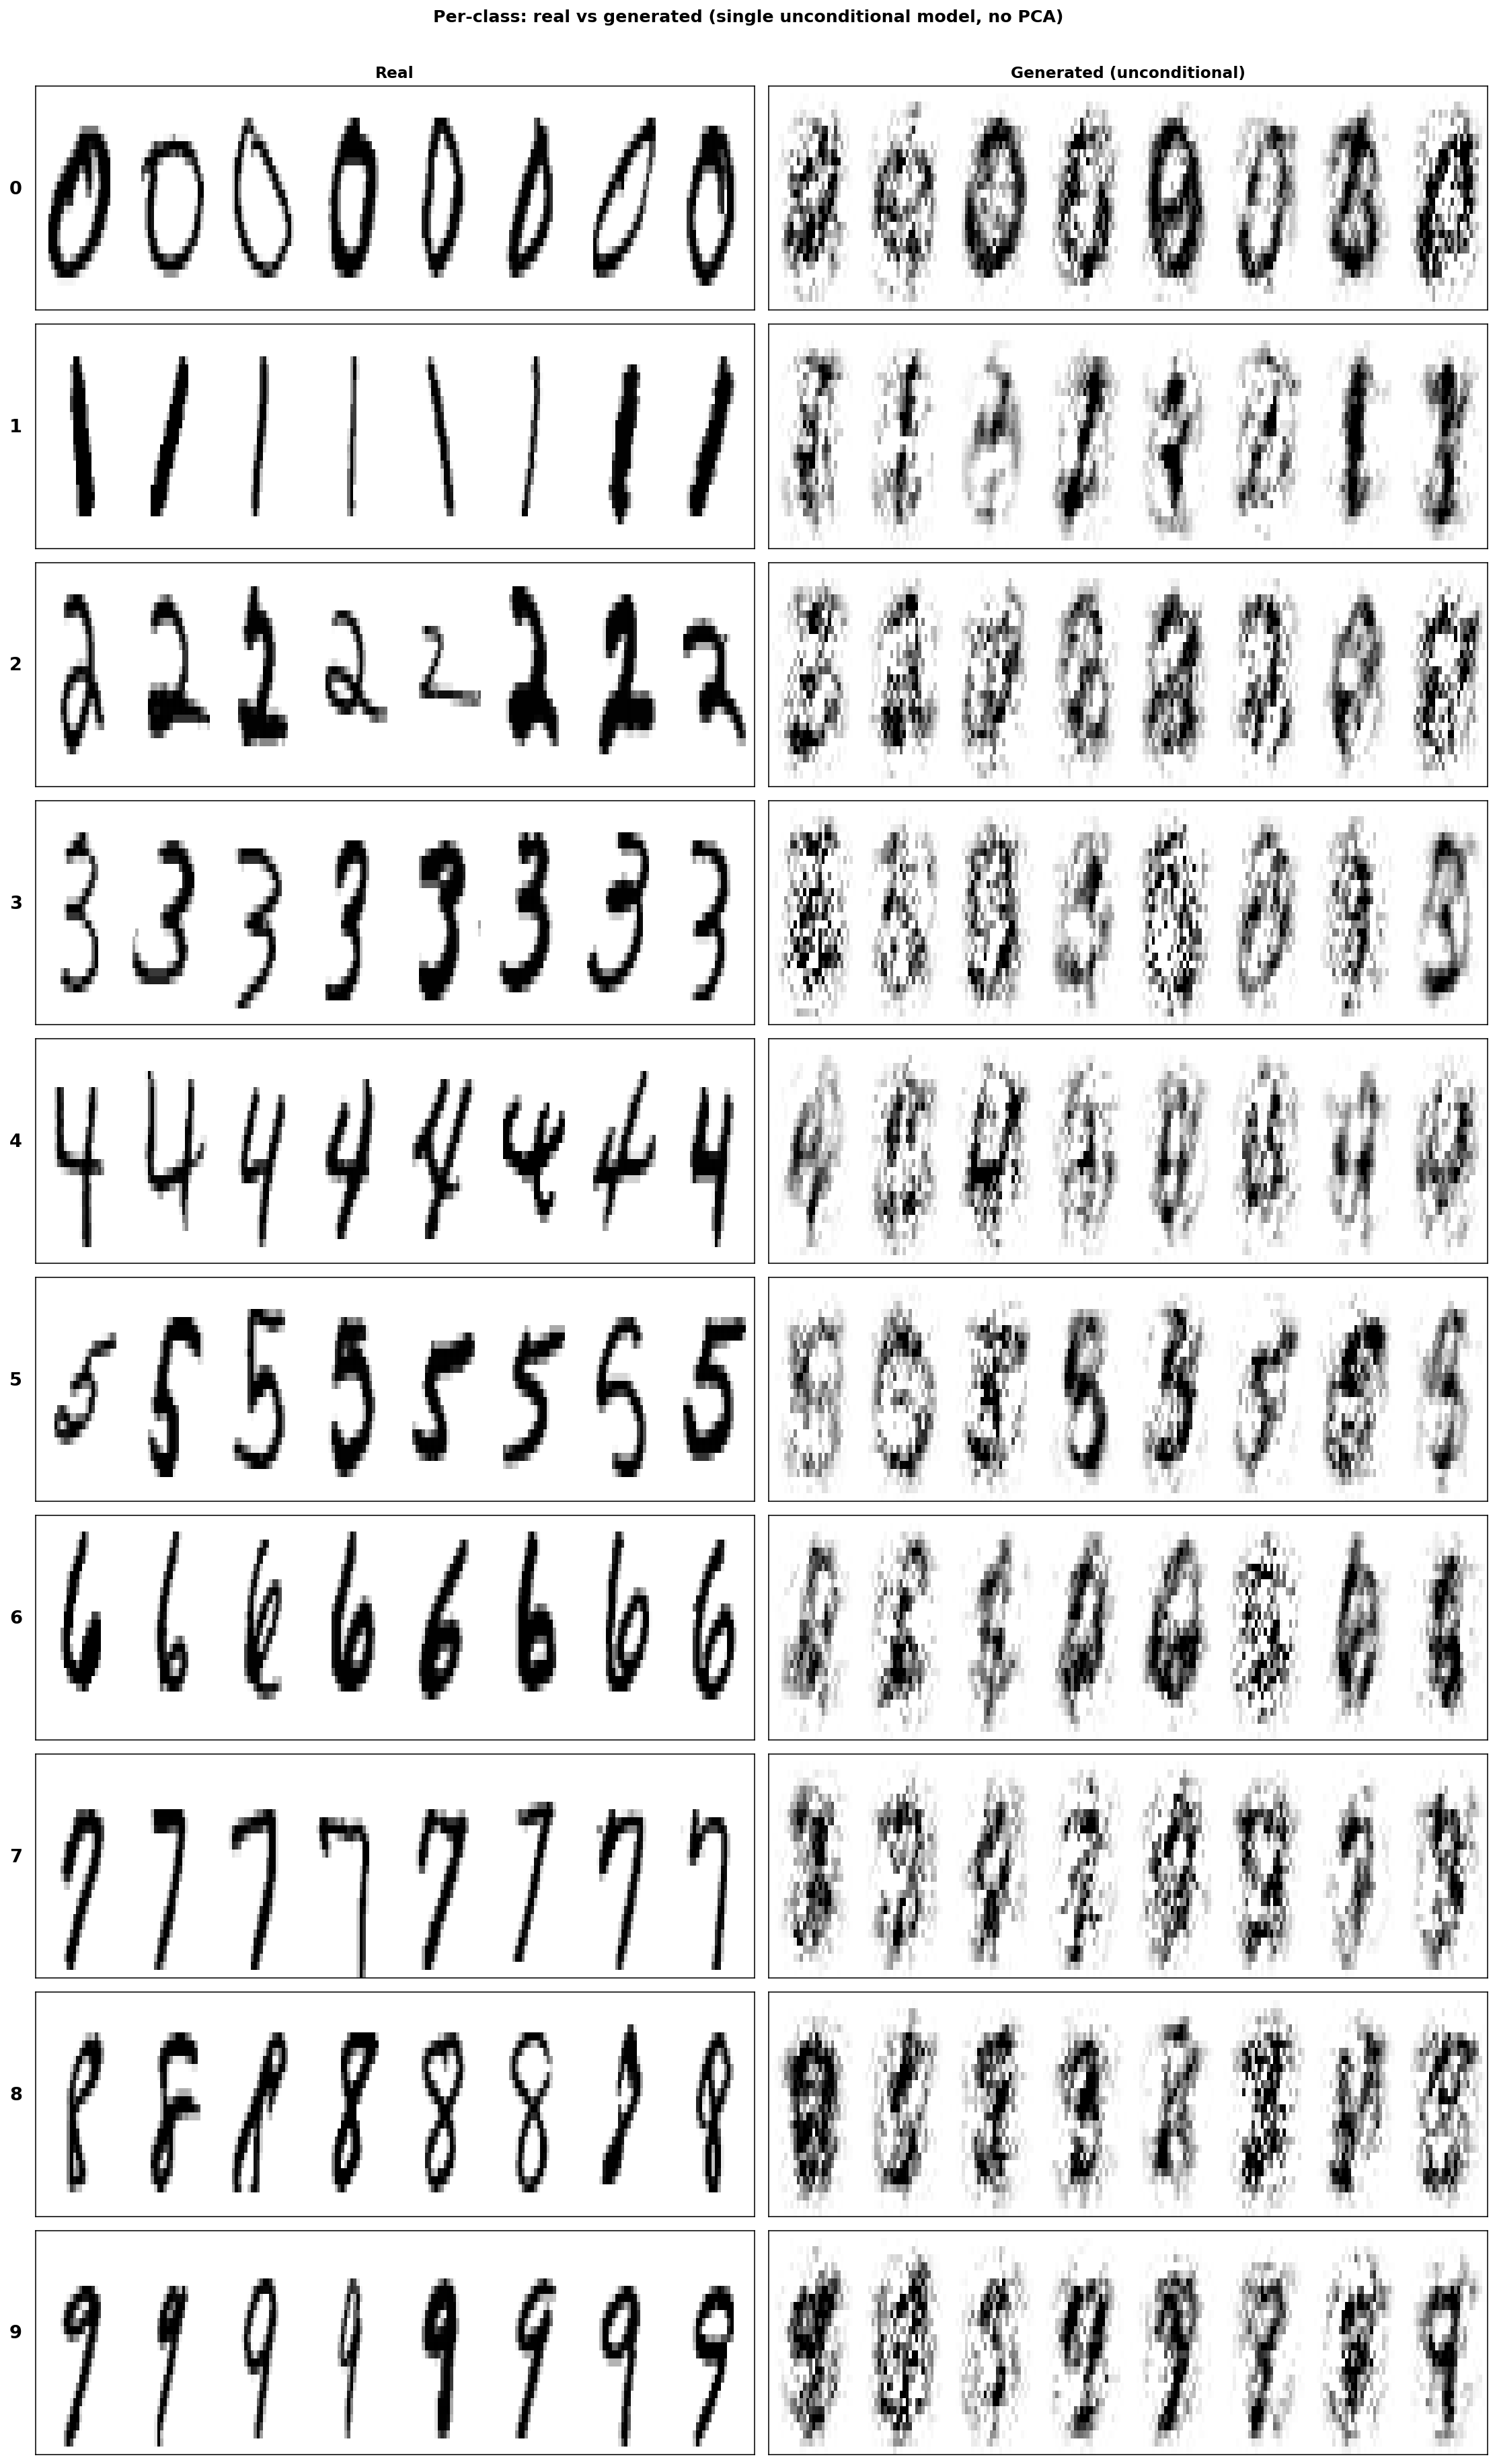

In [40]:
# Per-class: real vs generated
fig, axes = plt.subplots(10, 2, figsize=(16, 26))
for digit in range(10):
    show_digits(X_all[y_all==digit][:8], n=8, ax=axes[digit,0])
    gen_d = gen_pixels[gen_labels==digit][:8]
    if len(gen_d) > 0:
        show_digits(gen_d, n=min(8, len(gen_d)), ax=axes[digit,1])
    axes[digit,0].set_ylabel(f'{digit}', fontsize=14, fontweight='bold', rotation=0, labelpad=15)
    if digit==0:
        axes[digit,0].set_title('Real', fontsize=12, fontweight='bold')
        axes[digit,1].set_title('Generated (unconditional)', fontsize=12, fontweight='bold')
fig.suptitle('Per-class: real vs generated (single unconditional model, no PCA)', fontweight='bold', fontsize=13, y=1.005)
plt.tight_layout(); plt.show()


---
## 3. Watch digits form: evolution of fresh samples


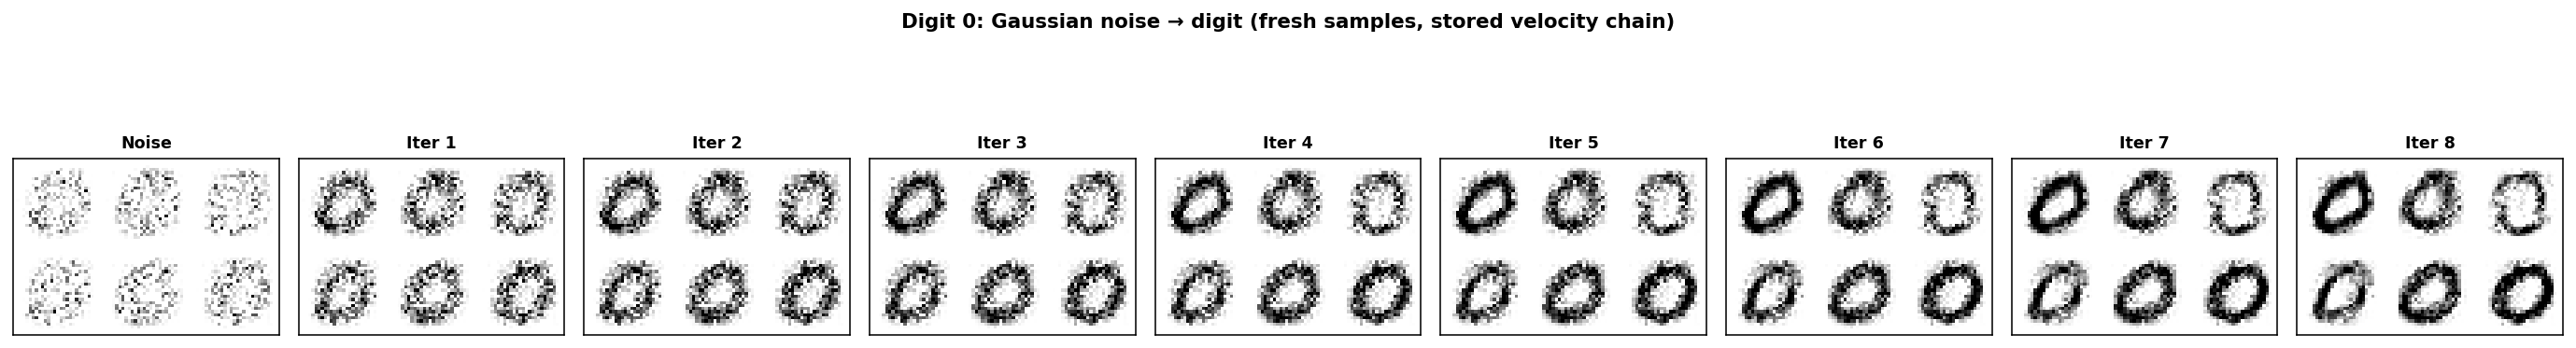

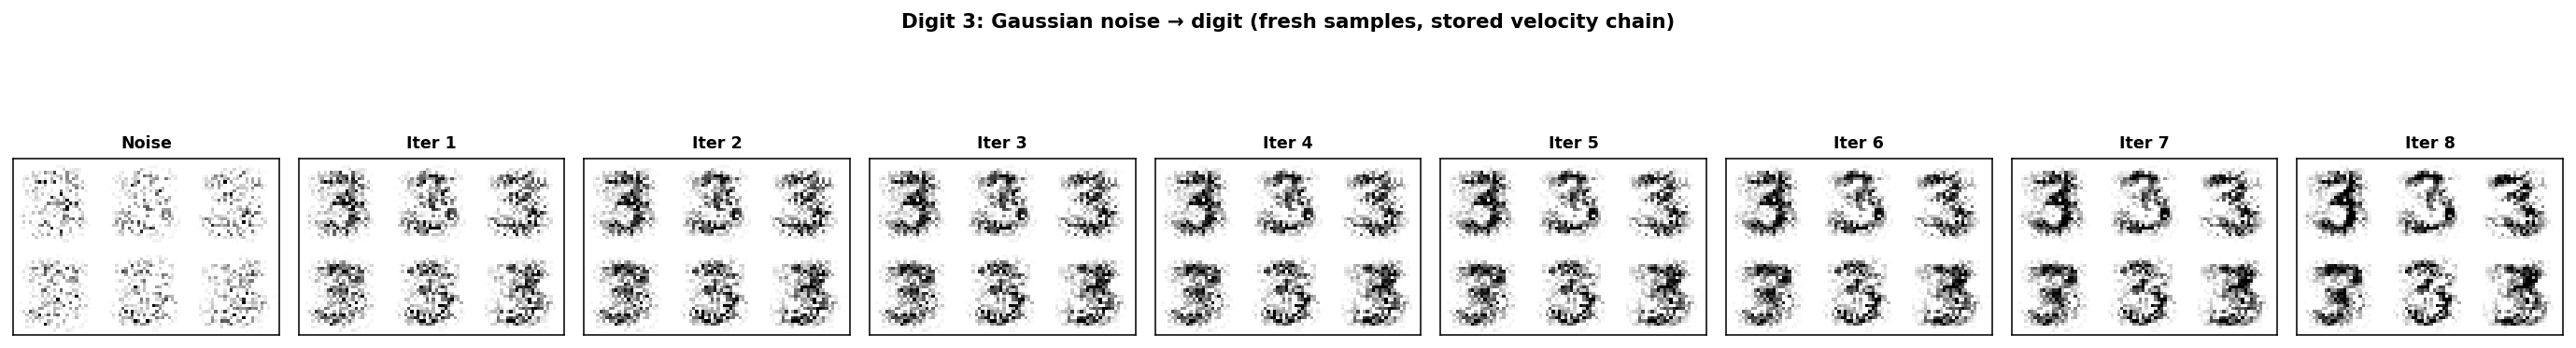

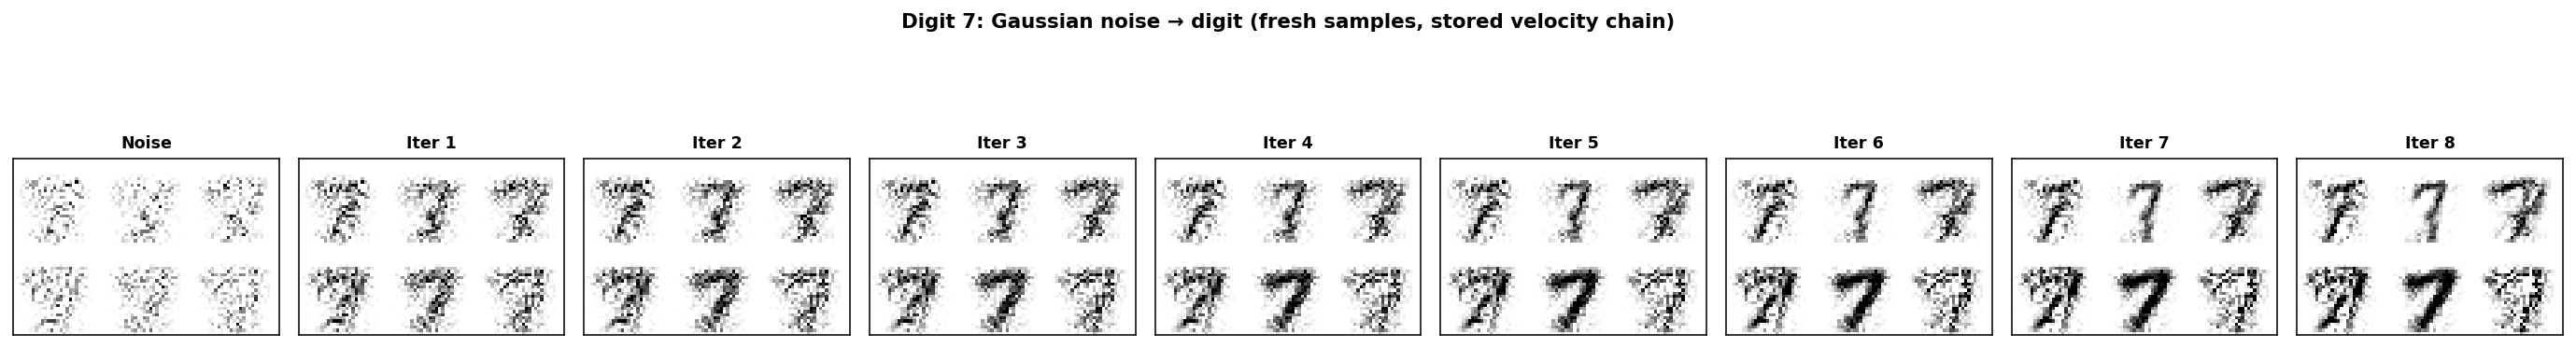

In [41]:
# Evolution: watch fresh noise become digits
for digit in [0, 3, 7]:
    r = results[digit]
    X0_viz = np.random.randn(6, d)
    res_viz = r['model'].transport(X0_viz)
    n_it = len(res_viz['snapshots'])

    fig, axes = plt.subplots(1, n_it, figsize=(n_it*2.2, 3.0))
    for it in range(n_it):
        snap = res_viz['snapshots'][it]
        pixels = np.clip(snap * r['scale'], 0, 1)
        grid = np.ones((28*2+1, 28*3+2)) * 0.0
        for j in range(min(6, len(pixels))):
            row, col = j//3, j%3
            grid[row*29:row*29+28, col*29:col*29+28] = pixels[j].reshape(28,28)
        ax = axes[it]
        ax.imshow(grid, cmap='gray_r', interpolation='nearest', vmin=0, vmax=1)
        ax.set_title('Noise' if it==0 else f'Iter {it}', fontsize=9, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f'Digit {digit}: Gaussian noise → digit (fresh samples, stored velocity chain)',
                 fontweight='bold', fontsize=11, y=1.05)
    plt.tight_layout(); plt.show()


In [42]:
# Summary stats
print('Per-digit SW1 (3 iterations):')
for digit in range(10): print(f'  Digit {digit}: {results[digit]["sw"]:.3f}  η_final={results[digit]["model"]._fit_result["lift_ratios"][-1]:.3f}')
print(f'\nMean SW1 (3 iter): {np.mean([results[digit]["sw"] for digit in range(10)]):.3f}')
print(f'Mean SW1 (1 iter): {np.mean([results_1iter[digit]["sw"] for digit in range(10)]):.3f}')
print(f'\nUnconditional SW1: {sliced_wasserstein1(res_all["particles"], X_test_all):.3f}')
print(f'Unconditional η:    {model_all._fit_result["lift_ratios"]}')


Per-digit SW1 (3 iterations):
  Digit 0: 0.182  η_final=0.324
  Digit 1: 0.189  η_final=0.266
  Digit 2: 0.218  η_final=0.345
  Digit 3: 0.216  η_final=0.322
  Digit 4: 0.220  η_final=0.313
  Digit 5: 0.179  η_final=0.330
  Digit 6: 0.180  η_final=0.317
  Digit 7: 0.213  η_final=0.309
  Digit 8: 0.204  η_final=0.315
  Digit 9: 0.195  η_final=0.294

Mean SW1 (3 iter): 0.200
Mean SW1 (1 iter): 0.270

Unconditional SW1: 0.108
Unconditional η:    [0.5256083901643789, 0.49042453941790054, 0.4135298410466873, 0.41625137904568676, 0.3823321724433861, 0.31590056661272814, 0.2612546058444458, 0.217725620907458, 0.18756948697581702, 0.1859334919500574]
